=== PROCESS ENGINEERING SIMULATION REPORT ===
Baseline Total Production Time : 3248.44 mins (54.14 hours)
Optimized Total Production Time: 2412.15 mins (40.20 hours)
Throughput Improvement         : 25.74% faster
Average Bus Cycle Time Saved   : 426.49 minutes per unit



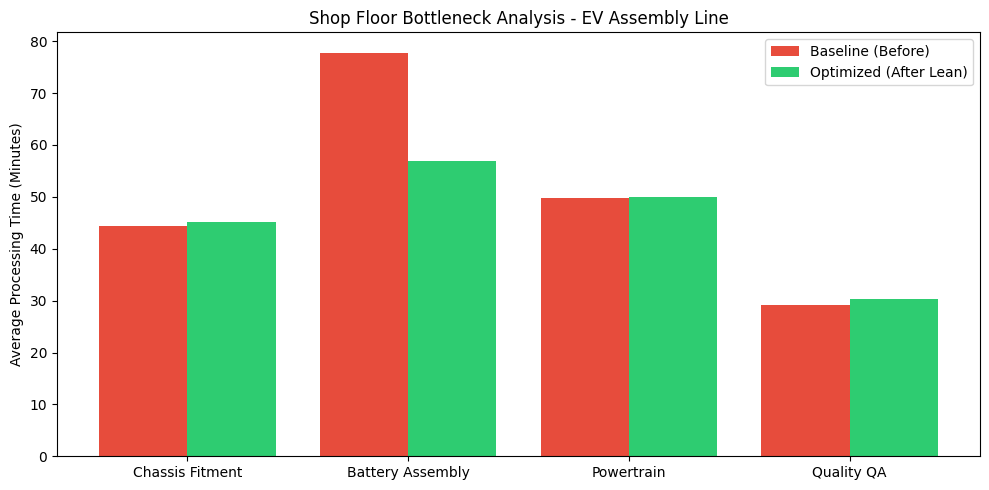

In [ ]:
import random
import matplotlib.pyplot as plt
import pandas as pd

# Set random seed for reproducibility
random.seed(42)

class EVAssemblyLineSimulation:
    def __init__(self, num_buses=50):
        self.num_buses = num_buses

        # Base cycle times in minutes for each station (Mean, Std Dev)
        self.base_times = {
            'Station 1: Chassis Assembly': (45, 5),
            'Station 2: Battery Integration': (75, 12),  # The clear bottleneck
            'Station 3: Powertrain Fitment': (50, 6),
            'Station 4: Quality Inspection': (30, 4)
        }

    def run_simulation(self, optimized=False):
        """Simulates the production line bus by bus."""
        station_names = list(self.base_times.keys())
        # Track when each station becomes free
        station_free_at = {station: 0.0 for station in station_names}

        # Track metrics for each bus
        bus_history = []

        for bus_id in range(1, self.num_buses + 1):
            current_time = 0.0  # Time the bus enters the factory
            bus_log = {'Bus_ID': bus_id}

            for i, station in enumerate(station_names):
                mean, std_dev = self.base_times[station]

                # Apply Lean Optimization to Station 2 if optimized flag is True
                if optimized and station == 'Station 2: Battery Integration':
                    mean = mean * 0.75  # 25% cycle time reduction via Lean optimization
                    std_dev = std_dev * 0.8

                # Generate actual processing time using a normal distribution
                processing_time = max(1.0, random.normalvariate(mean, std_dev))

                # Arrival time at this specific station
                arrival_time = current_time

                # Start time depends on if the station is free and if the bus has arrived
                start_time = max(arrival_time, station_free_at[station])
                wait_time = start_time - arrival_time
                end_time = start_time + processing_time

                # Update station availability and bus location tracking
                station_free_at[station] = end_time
                current_time = end_time

                # Log station metrics
                bus_log[f'{station}_Wait'] = wait_time
                bus_log[f'{station}_Process'] = processing_time

            bus_log['Total_Cycle_Time'] = current_time
            bus_history.append(bus_log)

        return pd.DataFrame(bus_history)

# ==========================================
# RUN SIMULATION & ANALYZE
# ==========================================

sim = EVAssemblyLineSimulation(num_buses=40)

# 1. Run Baseline (Before Lean Intervention)
df_baseline = sim.run_simulation(optimized=False)
baseline_total_time = df_baseline['Total_Cycle_Time'].max()
baseline_avg_cycle = df_baseline['Total_Cycle_Time'].mean()

# 2. Run Optimized (After Lean Intervention)
df_optimized = sim.run_simulation(optimized=True)
opt_total_time = df_optimized['Total_Cycle_Time'].max()
opt_avg_cycle = df_optimized['Total_Cycle_Time'].mean()

# ==========================================
# PRINT INDUSTRIAL METRICS REPORT
# ==========================================
print("=== PROCESS ENGINEERING SIMULATION REPORT ===")
print(f"Baseline Total Production Time : {baseline_total_time:.2f} mins ({(baseline_total_time/60):.2f} hours)")
print(f"Optimized Total Production Time: {opt_total_time:.2f} mins ({(opt_total_time/60):.2f} hours)")
print(f"Throughput Improvement         : {((baseline_total_time - opt_total_time)/baseline_total_time)*100:.2f}% faster")
print(f"Average Bus Cycle Time Saved   : {baseline_avg_cycle - opt_avg_cycle:.2f} minutes per unit\n")

# ==========================================
# VISUALIZE THE BOTTLENECK REMOVAL
# ==========================================
stations = ['Station 1: Chassis Assembly', 'Station 2: Battery Integration', 'Station 3: Powertrain Fitment', 'Station 4: Quality Inspection']
avg_process_baseline = [df_baseline[f'{s}_Process'].mean() for s in stations]
avg_process_opt = [df_optimized[f'{s}_Process'].mean() for s in stations]

x = range(len(stations))
plt.figure(figsize=(10, 5))
plt.bar([i - 0.2 for i in x], avg_process_baseline, width=0.4, label='Baseline (Before)', color='#e74c3c')
plt.bar([i + 0.2 for i in x], avg_process_opt, width=0.4, label='Optimized (After Lean)', color='#2ecc71')

plt.xticks(x, ['Chassis Fitment', 'Battery Assembly', 'Powertrain', 'Quality QA'])
plt.ylabel('Average Processing Time (Minutes)')
plt.title('Shop Floor Bottleneck Analysis - EV Assembly Line')
plt.legend()
plt.tight_layout()
plt.show()